In [1]:
from openpiv import tools, pyprocess, validation, filters, scaling

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import io
from PIL import Image
from IPython.display import Image as IPyImage, display
from matplotlib.ticker import FuncFormatter
import matplotlib.pyplot as plt
import sys
sys.path.append('/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/PIV/')   
sys.path.append('/Users/kjesta/Desktop/LABDATA/PIV/')
import imageio
import pathlib
import cmcrameri.cm as cm
import pandas as pd
from piv_func import perform_piv

import matplotlib.style as mplstyle
mplstyle.use(["ggplot", "fast"])

# Particle Image Velocimetry
#### Kjersti Stangeland, Spring 2026
**Analyzing**:
* f = 1.4 Hz
* A = 0.3 V
* D = 0.2 m
* H = 0.15 m

Run 2 out of 3

In [2]:
# Opening frames needed for analyzing two wave periods
ims = np.linspace(1250, 1516, 267)  # Adjusted to cover three periods (1250 to 1516)
frames = {}

for im in ims:
    im_int = int(im)
    img = tools.imread(f'/Users/kjesta/Desktop/LABDATA/PIV/f14a03/bitmap2/image_p{im_int}.bmp')
    frames[im_int] = img

In [3]:
T = 1/1.4  # wave period, seconds
fps = 125  # frames per second
dt = 1/fps  # time between frames, seconds
fpp = fps*T  # frames per period
images_needed = int(3*fpp)

print(f"Frames per period: {fpp:.2f}")
print(f"Time between frames: {dt:.4f} s")
print(f"Total images needed for three periods: {images_needed}")
print(f"Frames opened: {len(frames)}")

Frames per period: 89.29
Time between frames: 0.0080 s
Total images needed for three periods: 267
Frames opened: 267


In [4]:
timestamps = [i * dt + 10 for i in list(frames.keys())] # timestamps for one period, starting at 10 seconds

In [5]:
'''
Cutting out mid part of image. 
Want to avoid the free surface as the edge effects there
distort the velocity field.
I also match the indices to the reference photo to be sure the scaling is correct.
'''
y_min = 675
y_max = 1725

x_min = 15
x_max = 1250

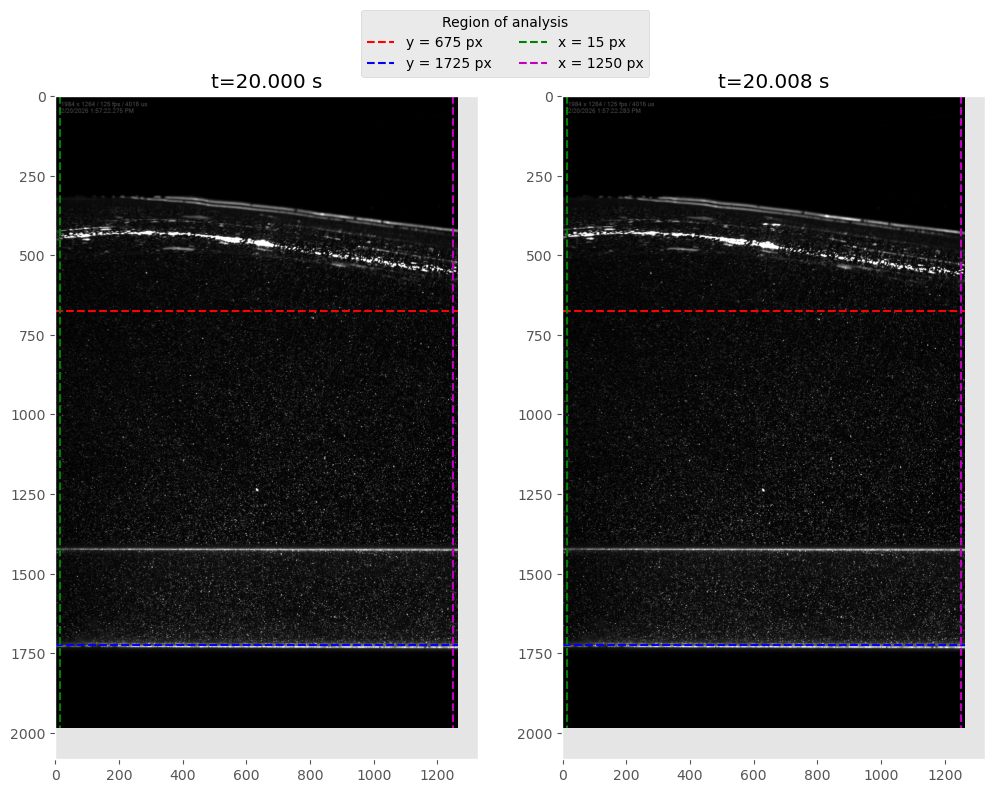

In [6]:
fig, ax =plt.subplots(1,2, figsize=(12,10))
ax[0].imshow(frames[1250], cmap='gray')
ax[0].hlines(y=y_min, xmin=0, xmax=frames[1250].shape[1], colors='r', linestyles='--', label=f'y = {y_min} px')
ax[0].hlines(y=y_max, xmin=0, xmax=frames[1250].shape[1], colors='b', linestyles='--', label=f'y = {y_max} px')
ax[0].vlines(x=x_min, ymin=0, ymax=frames[1250].shape[0], colors='g', linestyles='--', label=f'x = {x_min} px')
ax[0].vlines(x=x_max, ymin=0, ymax=frames[1250].shape[0], colors='m', linestyles='--', label=f'x = {x_max} px')
ax[0].set_title(f't={timestamps[0]:.3f} s')

ax[1].imshow(frames[1251], cmap='gray')
ax[1].set_title(f't={timestamps[1]:.3f} s')
ax[1].hlines(y=y_min, xmin=0, xmax=frames[1251].shape[1], colors='r', linestyles='--')
ax[1].hlines(y=y_max, xmin=0, xmax=frames[1251].shape[1], colors='b', linestyles='--')
ax[1].vlines(x=x_min, ymin=0, ymax=frames[1251].shape[0], colors='g', linestyles='--')
ax[1].vlines(x=x_max, ymin=0, ymax=frames[1251].shape[0], colors='m', linestyles='--')

ax[0].grid()
ax[1].grid()
fig.legend(title='Region of analysis', loc='upper center', bbox_to_anchor=(0.5, 0.92), ncol=2)

In [7]:
# Zoom in on area of interest
# Ignoring the surface and the bottom of the frame
zoom_frames = {}
for key in frames.keys():
    zoom_frames[key] = frames[key][y_min:y_max, x_min:x_max]

In [8]:
plate_top_index = 748

Text(0.5, 0.9, 'Raw, zoomed in, frames')

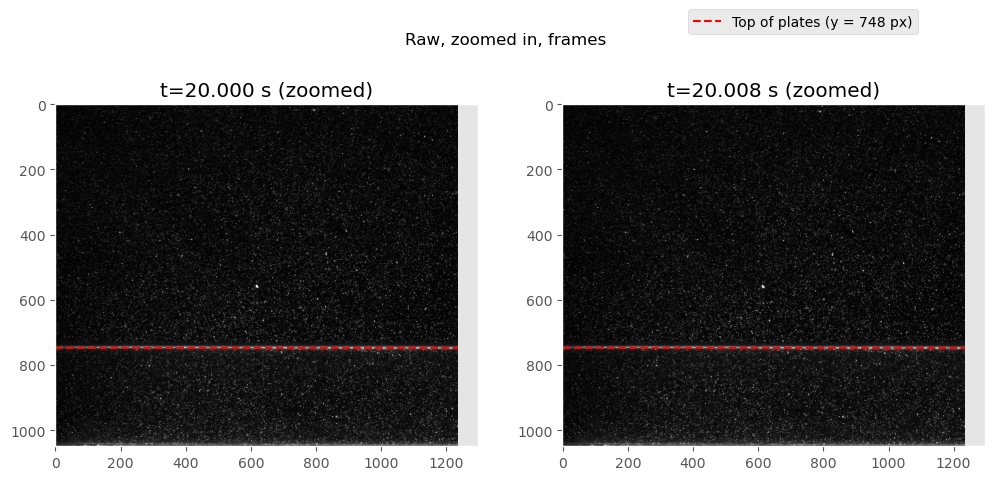

In [9]:
fig, ax =plt.subplots(1,2, figsize=(12,6))
ax[0].imshow(zoom_frames[1250], cmap='gray')
ax[0].set_title(f't={timestamps[0]:.3f} s (zoomed)')
ax[0].hlines(y=plate_top_index, xmin=0, xmax=zoom_frames[1250].shape[1], colors='r', linestyles='--', label=f'Top of plates (y = {plate_top_index} px)')

ax[1].imshow(zoom_frames[1251], cmap='gray')
ax[1].set_title(f't={timestamps[1]:.3f} s (zoomed)')
ax[1].hlines(y=plate_top_index, xmin=0, xmax=zoom_frames[1251].shape[1], colors='r', linestyles='--')
ax[0].grid()
ax[1].grid()

fig.legend(loc='upper right', bbox_to_anchor=(0.85, 0.95), ncol=2)
fig.suptitle('Raw, zoomed in, frames', y=0.9)

In [10]:
# Load reference image
reference = tools.imread('/Users/kjesta/Desktop/LABDATA/PIV/reference_p29.bmp')

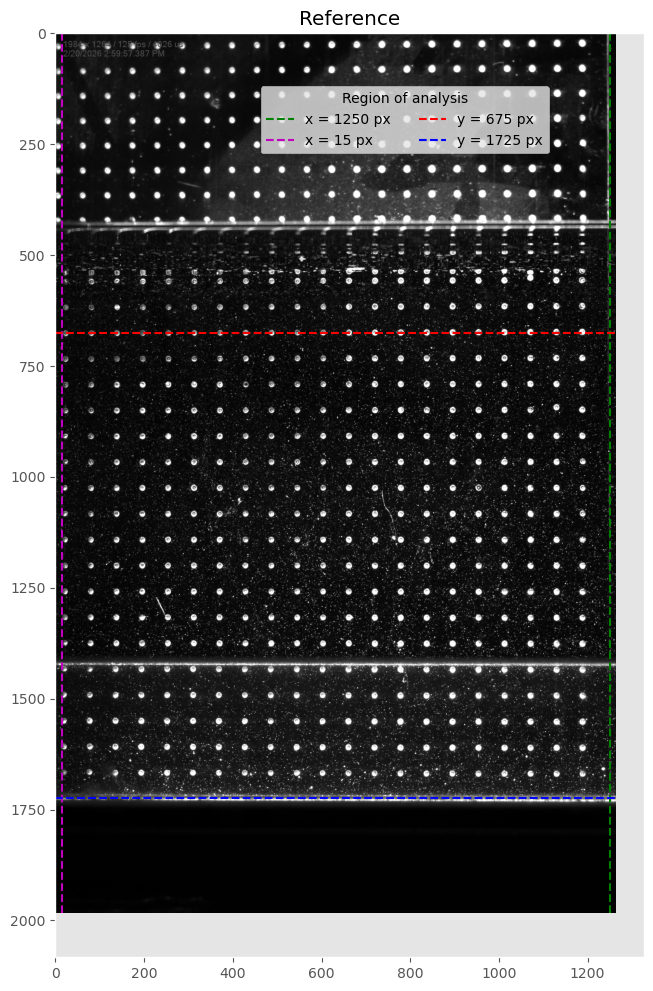

In [11]:
fig, ax =plt.subplots(1, figsize=(12, 12))
ax.imshow(reference, cmap='gray')
ax.vlines(x=x_max, ymin=0, ymax=reference.shape[0], colors='g', linestyles='--', label=f'x = {x_max} px')
ax.vlines(x=x_min, ymin=0, ymax=reference.shape[0], colors='m', linestyles='--', label=f'x = {x_min} px')
ax.hlines(y=y_min, xmin=0, xmax=reference.shape[1], colors='r', linestyles='--', label=f'y = {y_min} px')
ax.hlines(y=y_max, xmin=0, xmax=reference.shape[1], colors='b', linestyles='--', label=f'y = {y_max} px')
ax.legend(title='Region of analysis', loc='upper right', bbox_to_anchor=(0.85, 0.95), ncol=2)
ax.set_title('Reference')
ax.grid()

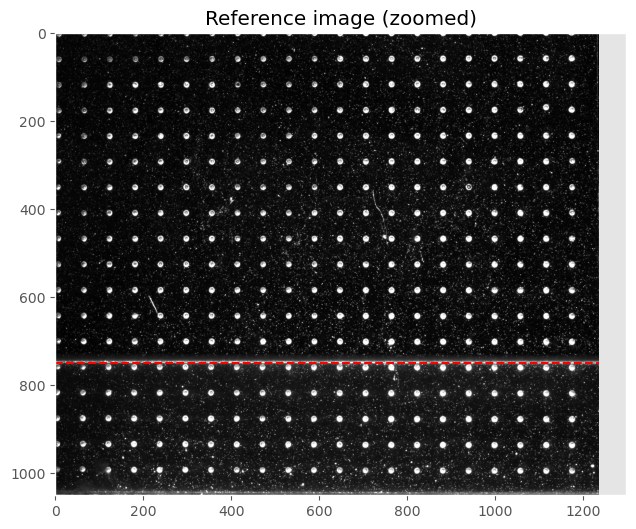

In [12]:
# Zoom in on reference image
reference_zoom = reference[y_min:y_max, x_min:x_max]

fig, ax =plt.subplots(1, figsize=(12,6))
ax.imshow(reference_zoom, cmap='gray')
ax.set_title('Reference image (zoomed)')
ax.hlines(y=plate_top_index, xmin=0, xmax=reference_zoom.shape[1], colors='r', linestyles='--')
ax.grid()

In [13]:
# Distance between pixel 15 and 1250 (in horizontal direction)
x_m = 0.21
# Distance between pixel 675 and 1725 (in vertical direction)
y_m = 0.18

# Calculate pixel to m scaling factors
x_scale = (x_max - x_min) / x_m  # pixel per m
y_scale = (y_max - y_min) / y_m  # pixel per m

print(f"x_scale = {x_scale:.3f} px/m, y_scale = {y_scale:.3f} px/m")
print(f'Percentage difference: {(x_scale-y_scale)/y_scale * 100:.2f}%')

# Average if appropriate
scaling_factor = (x_scale + y_scale) / 2
print(f"Average scaling factor: {scaling_factor:.3f} px/m")

x_scale = 5880.952 px/m, y_scale = 5833.333 px/m
Percentage difference: 0.82%
Average scaling factor: 5857.143 px/m


In [14]:
# Crop frames to region of interest
ims = np.linspace(1250, 1516, 267)
cropped_frames = {}

for im in ims:
    cropped_frames[int(im)] = frames[int(im)][y_min:y_max, x_min:x_max]

In [15]:
# Removing static background
static = np.median(list(cropped_frames.values()), axis=0)
cleaned_frames = {}
for key in cropped_frames.keys():
    cleaned_frames[key] = cropped_frames[key] - static

In [16]:
def depth_formatter(y_tick, pos):
        # depth: negative downward
        # Adding 0.02 m to shift the depth values so that it matches real water depth
        return f"{-(y_tick + 0.02):.2f}"

def x_phys_formatter(x_tick, pos):
        # Map image x → physical x (paddle at 8.06 m on the right)
        return f"{8.06 + (x_max - x_tick):.2f}"

In [17]:
# PIV parameters

window_size = 16  # interrogation window size (in pixels)
overlap = 8  # overlap between interrogation windows (in pixels)
search_area_size = 32  # search area size (in pixels)
stepsize = 1  # how many frames to skip between PIV analyses
threshold = 1.2  # sig2noise threshold for validation
max_iter = 10  
kernel_size = 2 

In [18]:
len(cleaned_frames)-1

266

In [19]:
# Lists for storing vertical velocity
# and vertical velocity gradient around the plates for each time step
w_bar = []
dw_bar = []

results = []

for key in range(1250, 1250+len(cleaned_frames)-1, stepsize):
    # Run PIV
    frame_a = cleaned_frames[key]
    frame_b = cleaned_frames[key + stepsize]
    
    idx_a = key - 1250
    idx_b = idx_a + stepsize

    time_a = timestamps[idx_a]
    time_b = timestamps[idx_b]

    dt = time_b - time_a

    # Perform PIV analysis
    u, v, sig2noise = pyprocess.extended_search_area_piv(
    frame_a, frame_b,
    window_size=window_size,
    overlap=overlap,
    dt=dt*stepsize,
    search_area_size=search_area_size)

    # Get coordinates
    x, y = pyprocess.get_coordinates(
    image_size=frame_a.shape,
    search_area_size=search_area_size,
    overlap=overlap)

    # 1) Signal-to-noise validation
    u, v, mask = validation.sig2noise_val(u, v, sig2noise, threshold=threshold)
    
    # 2) Local median validation
    u, v, mask = validation.local_median_val(
    u, v, u_threshold=50, v_threshold=50)

    flag_frac = np.mean(mask)
    print("Total flagged fraction after all validations: ", flag_frac)

    # 3) Replace outliers by local mean
    u, v = filters.replace_outliers(
    u, v,
    method='localmean',
    max_iter=max_iter,
    kernel_size=kernel_size)

    # 4) Scale to physical units
    x, y, u, v = scaling.uniform(x, y, u, v, scaling_factor=scaling_factor) 

    n_vec = u.size

    # Time indices for the two frames used in PIV
    idx_a = key - 1250
    time_a = timestamps[idx_a]
    idx_b = idx_a + stepsize
    time_b = timestamps[idx_b]

    # Calculate vorticity and velocity gradients
    curl_u = np.gradient(u, axis=0) # du/dz
    curl_w = np.gradient(v, axis=1) # dw/dx
    curl = curl_u - curl_w  # vorticity
    grad_u = np.gradient(u, axis=1) # du/dx
    grad_w = np.gradient(v, axis=0) # dw/dz

    # Find location of top of plates in physical units (m) and corresponding index in y array
    plate_top_m = plate_top_index/scaling_factor
    y_idx_plate_top = (np.abs(y[:, 0] - plate_top_m)).argmin()

    # Find average vertical velocity in the region of the plates
    no_w_vec = np.shape(v[y_idx_plate_top, :])
    w_mean = np.mean(v[y_idx_plate_top, :])
    w_bar.append(w_mean)
    dw_bar.append(np.mean(grad_w[y_idx_plate_top, :]))

    results.append({
        'time_a': time_a,
        'time_b': time_b,
        'w_bar': w_bar[-1],
        'dw_bar': dw_bar[-1],
        '# of vectors': n_vec,
        'flag_fraction': flag_frac,
        '# w vectors in mean': no_w_vec
    })

    # Origin (0,0) is at the top left corner of the cleaned image, 
    # such that x increases to the right, y increases downwards
    # For plotting, I want to show the location in the tank, so I modify x to match location in the tank
    # and y to be negative and descending downwards to be depth

    x_max = x.max()
    y_min = y.min()

    # Plot the velocity field
    fig, ax = plt.subplots(1, 2, figsize=(14,6))

    ax[0].imshow(cleaned_frames[key+1], cmap='gray_r', alpha=0.5, extent=(x.min(), x.max(), y.max(), y.min()))
    ax[1].imshow(cleaned_frames[key+1], cmap='gray_r', alpha=0.5, extent=(x.min(), x.max(), y.max(), y.min()))

    # Colorbar limits for vertical velocity
    vmin = -0.1
    vmax = 0.1
    
    # Colorbar limits for velocity magnitude
    umin = 0
    umax = 0.12

    step_x = 2
    step_z = 1

    # Filled contour of velocity magnitude
    im = ax[0].contourf(x, y, np.sqrt(u**2 + v**2), cmap=cm.imola, levels=np.linspace(umin, umax, 51), extend='max')
    # Quiver plot of velocity vectors, subsampled for better visibility
    im1 = ax[0].quiver(x[::step_z, ::step_x], y[::step_z, ::step_x], -u[::step_z, ::step_x], v[::step_z, ::step_x], color='white', scale=5)
    ax[0].hlines(y=plate_top_m, xmin=x.min(), xmax=x.max(), colors='black', linestyles='--', linewidth=1, label='Top of plates')
    cbar = plt.colorbar(im, label='Velocity magnitude (m/s)', shrink=0.8)
    ax[0].set_title(f't={timestamps[idx_b]:.3f} s')
    ax[0].grid()
    ax[0].legend(loc='lower left')

    step_z = 5
    step_x = 1
    # Filled contour plot of vertical velocity
    im1 = ax[1].contourf(x, y, v, cmap=cm.vik, levels=np.linspace(vmin, vmax, 51), extend='both')

    cbar1 = plt.colorbar(
    im1, extend='both',
    label='Vertical velocity (m/s)', shrink=0.8)

    ax[1].set_title(f't={timestamps[idx_b]:.3f} s')
    ax[1].grid()

    #ax[1].hlines(
    #y=y[y_idx_plate_top, :], xmin=x.min(), xmax=x.max(),
    #colors='gray', linewidth=0.5, linestyles='--',
    #label=rf'$\bar w$ = {w_bar[-1]:.4f} m/s')

    #ax[1].hlines(
    #y=y[y_idx_plate_top-1, :], xmin=x.min(), xmax=x.max(),
    #colors='gray', linewidth=0.5, linestyles='--',
    #label=rf'$\partial\bar w / \partial z$ = {dw_bar[-1]:.4f} m/s')

    #ax[1].fill_between(x[0, :], y[y_idx_plate_top-1, :], y[y_idx_plate_top, :], color='gray', alpha=0.3)

    ax[1].hlines(y=plate_top_m, xmin=x.min(), xmax=x.max(), colors='black', linestyles='--', linewidth=1, label=rf'$\bar w$ = {w_bar[-1]:.4f} m/s')
    ax[1].legend(loc='lower left')

    for a in ax:
        a.xaxis.set_major_formatter(FuncFormatter(x_phys_formatter))
        a.set_xlabel("x [m]")
        a.yaxis.set_major_formatter(FuncFormatter(depth_formatter))
        a.set_ylabel("z [m]")

    plt.savefig(f'/Users/kjesta/Desktop/LABDATA/PIV/Results/figs/f14a03/vel_field_{key}_r2.png', dpi=300)
    plt.close(fig)

    # Plot the vorticity and velocity gradients

    vmin = -0.1
    vmax = 0.1
    vlevs = np.linspace(vmin, vmax, 51)

    umin = -0.1
    umax = 0.1
    ulevs = np.linspace(umin, umax, 51)

    wmin = -0.01
    wmax = 0.01
    wlevs = np.linspace(wmin, wmax, 51)

    fig, ax = plt.subplots(1, 3, figsize=(18,6))
    im = ax[0].contourf(x, y, curl, alpha=0.5, levels=vlevs, cmap=cm.vik, extend='both')
    ax[0].imshow(cleaned_frames[key+1], cmap='gray_r', alpha=0.5,extent=(x.min(), x.max(), y.max(), y.min()))
    cbar = plt.colorbar(im, ax=ax[0], label='Vorticity (1/s)', shrink=0.7)
    ax[0].grid()

    im = ax[1].contourf(x, y, grad_u, alpha=0.5, cmap=cm.vik, levels=ulevs, extend='both')
    cbar = plt.colorbar(im, ax=ax[1], label=r'$\partial u / \partial x$ (1/s)', shrink=0.7)
    ax[1].imshow(cleaned_frames[key+1], cmap='gray_r', alpha=0.5, extent=(x.min(), x.max(), y.max(), y.min()))
    ax[1].grid()

    im = ax[2].contourf(x, y, grad_w, alpha=0.5, cmap=cm.vik, levels=wlevs, extend='both')
    cbar = plt.colorbar(im, ax=ax[2], label=r'$\partial w / \partial z$ (1/s)', shrink=0.7)
    ax[2].imshow(cleaned_frames[key+1], cmap='gray_r', alpha=0.5, extent=(x.min(), x.max(), y.max(), y.min()))
    ax[2].grid()
    fig.suptitle(f't = {timestamps[idx_b]:.3f} s', y=0.9)

    for a in ax:
        a.xaxis.set_major_formatter(FuncFormatter(x_phys_formatter))
        a.set_xlabel("x [m]")
        a.yaxis.set_major_formatter(FuncFormatter(depth_formatter))
        a.set_ylabel("z [m]")
        
    plt.tight_layout()  
    plt.savefig(f'/Users/kjesta/Desktop/LABDATA/PIV/Results/figs/f14a03/curl_grad_{key}_r2.png', dpi=300)
    plt.close(fig)

r2 = pd.DataFrame(results)

Total flagged fraction after all validations:  0.3141814865481076
Total flagged fraction after all validations:  0.320109439124487
Total flagged fraction after all validations:  0.307797537619699
Total flagged fraction after all validations:  0.2913816689466484
Total flagged fraction after all validations:  0.2950296397628819
Total flagged fraction after all validations:  0.28454172366621067
Total flagged fraction after all validations:  0.2954856361149111
Total flagged fraction after all validations:  0.302781577747378
Total flagged fraction after all validations:  0.2818057455540356
Total flagged fraction after all validations:  0.2913816689466484
Total flagged fraction after all validations:  0.2895576835385317
Total flagged fraction after all validations:  0.2922936616507068
Total flagged fraction after all validations:  0.2836297309621523
Total flagged fraction after all validations:  0.2836297309621523
Total flagged fraction after all validations:  0.2722298221614227
Total flagge

In [20]:
r2.to_csv('/Users/kjesta/Desktop/LABDATA/PIV/results/f14a03_res_r2.csv', index=False)